,Congestión (prom),Congestión (±err),Atraso (prom min),Atraso (±err),Desvíos (prom),Desvíos (±err)
λ,,,,,,
0.02,0.043478,0.000000e+00,0.281818,9.383097e-18,0.000000,0.000000e+00
0.10,0.304000,0.000000e+00,1.735185,3.753239e-17,0.112000,2.345774e-18
0.20,0.523404,1.876619e-17,3.001342,7.506478e-17,0.348936,9.383097e-18
0.50,0.814882,1.876619e-17,0.888742,1.876619e-17,0.705989,0.000000e+00
1.00,0.967593,0.000000e+00,0.000000,0.000000e+00,0.802778,1.876619e-17


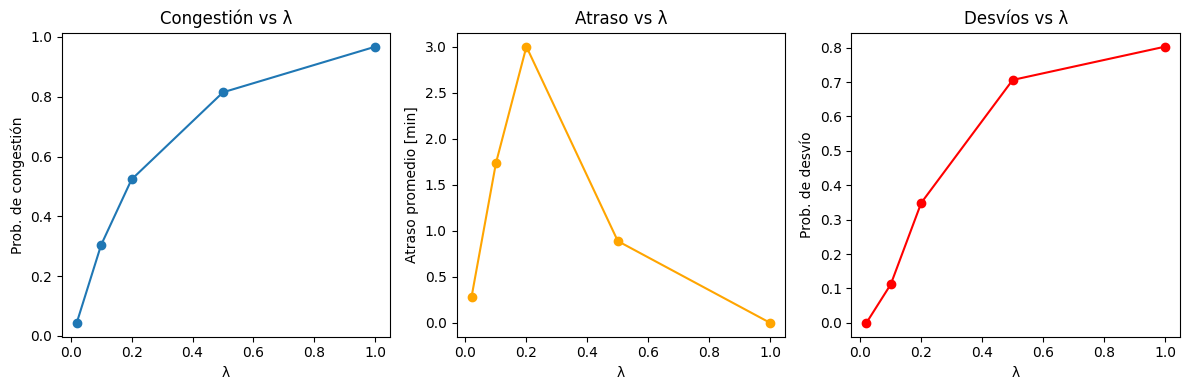

In [2]:


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from main import Simulador , SimuladorSinCongestion

LAMBDAS = [0.02, 0.1, 0.2, 0.5, 1.0]
N_SIM = 35   # número de réplicas Monte Carlo 

# =========================
# Función para correr simulaciones
# =========================
def correr_montecarlo(lam, n_rep=N_SIM):
    congestion_props = []
    atrasos = []
    desviados = []

    for _ in range(n_rep):
        sim = Simulador(seed=50)
        sim.simular_dia(lam)

        # --- congestión: % de aviones que alguna vez estuvieron ajustando
        aviones_congestionados = set(
            h["id"] for h in sim.historial if h["estado"] == "AJUSTANDO"
        )
        total_inbound = len(sim.aviones)
        prop_cong = len(aviones_congestionados) / max(1, total_inbound)
        congestion_props.append(prop_cong)

        # --- atraso promedio
        atrasos_rep = [a.retraso for a in sim.finalizados if a.estado == "ATERRIZADO"]
        atrasos.append(np.mean(atrasos_rep) if atrasos_rep else 0)

        # --- desvíos
        desv = sum(1 for a in sim.aviones.values() if a.estado == "DESVIADO") / max(1, len(sim.aviones))
        desviados.append(desv)

    return {
        "cong_mean": np.mean(congestion_props),
        "cong_std": np.std(congestion_props) / np.sqrt(n_rep),
        "delay_mean": np.mean(atrasos),
        "delay_std": np.std(atrasos) / np.sqrt(n_rep),
        "div_mean": np.mean(desviados),
        "div_std": np.std(desviados) / np.sqrt(n_rep),
    }



# =========================
# Correr experimentos
# =========================
resultados = {}
for lam in LAMBDAS:
    resultados[lam] = correr_montecarlo(lam)

# =========================
# Mostrar resultados
# =========================
df = pd.DataFrame(resultados).T
df.index.name = "λ"
df.columns = [
    "Congestión (prom)", "Congestión (±err)",
    "Atraso (prom min)", "Atraso (±err)",
    "Desvíos (prom)", "Desvíos (±err)"
]
display(df)

# =========================
# Gráficos
# =========================
plt.figure(figsize=(12,4))

# Congestión
plt.subplot(1,3,1)
plt.errorbar(df.index, df["Congestión (prom)"], yerr=df["Congestión (±err)"], fmt='-o')
plt.xlabel("λ")
plt.ylabel("Prob. de congestión")
plt.title("Congestión vs λ")

# Atrasos
plt.subplot(1,3,2)
plt.errorbar(df.index, df["Atraso (prom min)"], yerr=df["Atraso (±err)"], fmt='-o', color="orange")
plt.xlabel("λ")
plt.ylabel("Atraso promedio [min]")
plt.title("Atraso vs λ")

# Desvíos
plt.subplot(1,3,3)
plt.errorbar(df.index, df["Desvíos (prom)"], yerr=df["Desvíos (±err)"], fmt='-o', color="red")
plt.xlabel("λ")
plt.ylabel("Prob. de desvío")
plt.title("Desvíos vs λ")

plt.tight_layout()
plt.show()


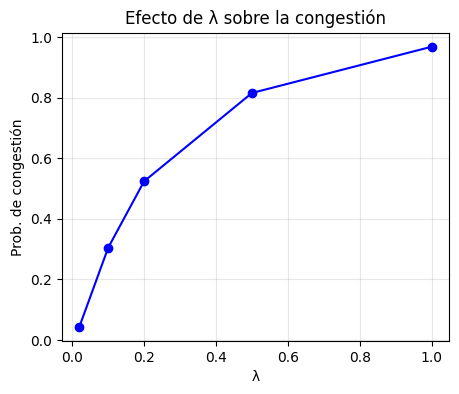

In [6]:
# 1) ¿El aumento de λ incrementa la frecuencia de congestiones?
plt.figure(figsize=(5,4))
plt.errorbar(
    df.index, df["Congestión (prom)"], 
    yerr=df["Congestión (±err)"], fmt='-o', color="blue"
)
plt.xlabel("λ")
plt.ylabel("Prob. de congestión")
plt.title("Efecto de λ sobre la congestión")
plt.grid(alpha=0.3)
plt.show()

# Efecto de λ sobre la congestión

El gráfico muestra cómo varía la **probabilidad de congestión** en función de la tasa de arribos (λ).  

- Para valores bajos de λ (ejemplo 0.02), la probabilidad de congestión es cercana a 0.  
  Los aviones llegan con suficiente separación y no necesitan reducir su velocidad.  
- A medida que λ aumenta, los arribos son más frecuentes y se incrementa la interacción entre aviones.  
  Esto obliga a muchos a **ajustar su velocidad** para mantener la separación mínima de seguridad.  
- Con λ = 0.2 la congestión ya aparece en más de la mitad de los vuelos.  
- A partir de λ = 0.5, la congestión se vuelve casi inevitable: más del 80% de los aviones experimentan reducción de velocidad.  
- En el extremo λ = 1, prácticamente todos los aviones sufren congestión, ya que la tasa de arribos es superior a la capacidad natural del sistema.  

## Interpretación

El aumento de λ **incrementa claramente la frecuencia de congestiones**.  
Esto confirma que el sistema no puede absorber tasas de arribos elevadas sin que se produzcan demoras operativas.


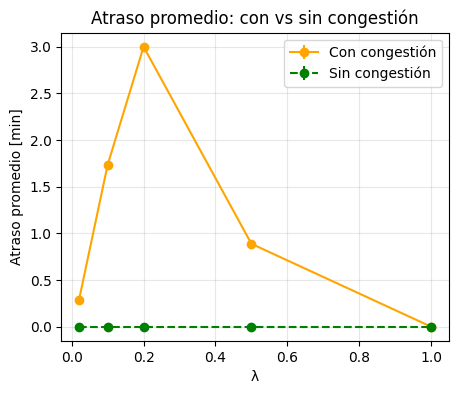

In [8]:
# 2) ¿Cuál es el atraso promedio vs lo que sucedería sin congestión?
# --- correr SimuladorSinCongestion ---
resultados_sin_cong = {}
for lam in LAMBDAS:
    atrasos = []
    for _ in range(N_SIM):
        sim = SimuladorSinCongestion(seed=np.random.randint(0, 500))
        sim.simular_dia(lam)
        atrasos_rep = [a.retraso for a in sim.finalizados if a.estado == "ATERRIZADO"]
        atrasos.append(np.mean(atrasos_rep) if atrasos_rep else 0)
    resultados_sin_cong[lam] = (np.mean(atrasos), np.std(atrasos)/np.sqrt(N_SIM))

# --- graficar comparación ---
plt.figure(figsize=(5,4))
plt.errorbar(
    df.index, df["Atraso (prom min)"], 
    yerr=df["Atraso (±err)"], fmt='-o', color="orange", label="Con congestión"
)
plt.errorbar(
    resultados_sin_cong.keys(),
    [m for m, _ in resultados_sin_cong.values()],
    yerr=[e for _, e in resultados_sin_cong.values()],
    fmt='--o', color="green", label="Sin congestión"
)
plt.xlabel("λ")
plt.ylabel("Atraso promedio [min]")
plt.title("Atraso promedio: con vs sin congestión")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Atraso promedio: con vs sin congestión

El gráfico compara el **atraso promedio de los aviones** en función de la tasa de arribos (λ), considerando dos escenarios:

- **Sin congestión (verde, línea discontinua):**  
  Todos los aviones vuelan siempre a su velocidad máxima permitida.  
  El atraso es prácticamente **cero** en todos los valores de λ, ya que nunca se obliga a reducir la velocidad.

- **Con congestión (naranja, línea continua):**  
  El atraso aparece cuando los aviones deben **reducir su velocidad** para mantener la separación mínima.  
  - Para λ muy bajos (0.02), los atrasos son pequeños porque casi nunca se genera congestión.  
  - El **máximo atraso promedio ocurre en λ ≈ 0.2**, donde los aviones se ven obligados a frenar con frecuencia.  
  - A medida que λ aumenta hacia 0.5 y 1.0, los atrasos disminuyen: el sistema ya no puede acumular demoras porque los aviones directamente son **desviados** antes de poder aterrizar.

## Interpretación

- El atraso promedio no crece de manera monótona con λ.  
- Existe un punto intermedio (alrededor de λ = 0.2) donde los aviones **acumulan más demoras**.  
- En cambio, para λ altos, la sobrecarga del sistema se manifiesta más en **desvíos masivos** que en atrasos prolongados.


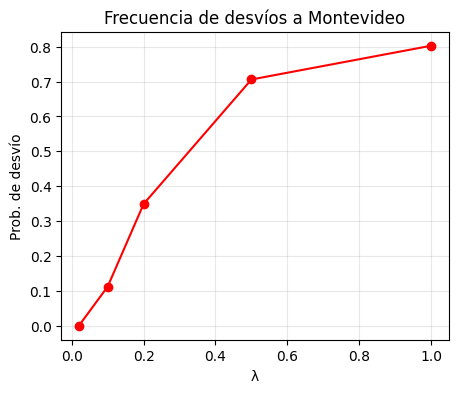

In [9]:
# 3) ¿Con qué frecuencia ocurre un desvío a Montevideo?
plt.figure(figsize=(5,4))
plt.errorbar(
    df.index, df["Desvíos (prom)"], 
    yerr=df["Desvíos (±err)"], fmt='-o', color="red"
)
plt.xlabel("λ")
plt.ylabel("Prob. de desvío")
plt.title("Frecuencia de desvíos a Montevideo")
plt.grid(alpha=0.3)
plt.show()


# Frecuencia de desvíos a Montevideo

El gráfico muestra la **probabilidad de que un avión sea desviado a Montevideo** en función de la tasa de arribos (λ):

- Para **λ muy bajo (0.02)**, los desvíos son prácticamente **nulos**, ya que el sistema no se congestiona.  
- A partir de **λ = 0.1 y 0.2**, comienzan a aparecer desvíos: algunos aviones no pueden insertarse en la cola y deben abortar el aterrizaje.  
- En **λ = 0.5**, la probabilidad de desvío supera el **70%**, lo que indica que la mayoría de los aviones no logra aterrizar en AEP.  
- Con **λ = 1.0**, los desvíos alcanzan alrededor del **80%**, mostrando que el sistema colapsa casi por completo.

## Interpretación

- La probabilidad de desvío **crece de manera monótona con λ**.  
- A diferencia del atraso promedio, aquí no hay un punto intermedio: cuanto mayor es la tasa de arribos, mayor es la fracción de aviones que deben desviarse.  
- Esto refleja que, bajo alta demanda, el aeropuerto **responde desviando vuelos** en lugar de acumular atrasos indefinidos.


In [11]:
##video para simulación con congestión para λ = 0.02. (hay congestión)
from main import animate_simulation_aviones, animate_simulation, Simulador
import numpy as np

titulo = "Video_congestion_0.2"
titulo2 = "Video_congestión_0.2_dia_completo"
simulacion = Simulador(seed=np.random.randint(0, 500))
simulacion.simular_dia(lam=0.2)  

animate_simulation_aviones(simulacion, titulo)
animate_simulation(simulacion, titulo2)